In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow 
from tensorflow.keras.datasets import cifar10

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Cifar 10 Classes")
for i, class_name in enumerate(class_names,1):
  print(f"{i}. {class_name.capitalize()}")

Cifar 10 Classes
1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck


In [4]:
print("Loading CIFAR-10 dataset...")
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

Loading CIFAR-10 dataset...


In [5]:
print(X_train.shape,y_train.shape),
print(X_test.shape,y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [6]:
print(X_train.min()-X_train.max())

1


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11020\4268247094.py:1: RuntimeWarning: overflow encountered in scalar subtract
  print(X_train.min()-X_train.max())


In [7]:
# Normalize pixel values to [0, 1]
x_train = X_train.astype('float32') / 255.0
x_test =X_test.astype('float32') / 255.0

In [8]:
# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()


In [9]:
print("✓ Data preprocessing complete")
print(f"  Training set normalized: {x_train.min():.2f} - {x_train.max():.2f}")
print(f"  Shape: {x_train.shape}")
print(f"  Labels: {y_train.shape}")

✓ Data preprocessing complete
  Training set normalized: 0.00 - 1.00
  Shape: (50000, 32, 32, 3)
  Labels: (50000,)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense, MaxPooling2D,Flatten,BatchNormalization,Dropout

In [11]:
model = Sequential()
# Block 1
model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 2
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(256,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10,activation='softmax'))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
# Compile the model
model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

In [16]:
history = model.fit(x_train,y_train,
                    validation_data=(x_test,y_test),
                    epochs=50,
                    callbacks = early_stopping,
                    batch_size=128)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 139s 338ms/step - accuracy: 0.4396 - loss: 1.6672 - val_accuracy: 0.3235 - val_loss: 2.0353
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 132s 337ms/step - accuracy: 0.6180 - loss: 1.0746 - val_accuracy: 0.6066 - val_loss: 1.1451
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 150s 382ms/step - accuracy: 0.6861 - loss: 0.8843 - val_accuracy: 0.6555 - val_loss: 1.0294
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 237s 473ms/step - accuracy: 0.7323 - loss: 0.7674 - val_accuracy: 0.7440 - val_loss: 0.7550
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 269s 645ms/step - accuracy: 0.7561 - loss: 0.6944 - val_accuracy: 0.7641 - val_loss: 0.6747
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 555ms/step - accuracy: 0.7776 - loss: 0.6360 - val_accuracy: 0.7510 - val_loss: 0.7572
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 291s 628ms/step - accuracy: 0.7962 - loss: 0.5850 - val_accuracy: 0.7981 - val_loss: 0.5908
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 179s 457ms/step - accuracy: 0.8113 -

In [17]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print("="*50)
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print("="*50)


MODEL EVALUATION
Test Loss: 0.4854
Test Accuracy: 85.56%
Train Loss: 0.0708
Train Accuracy: 97.79%


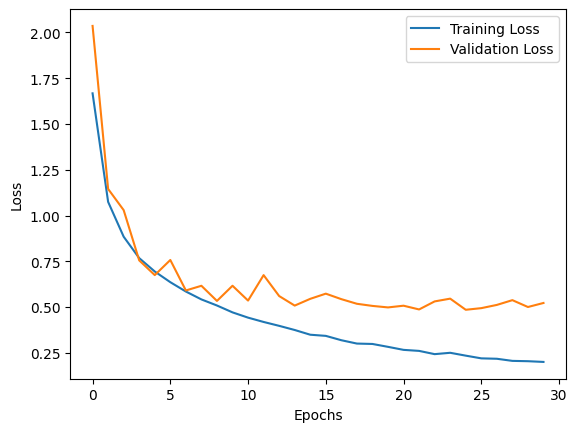

In [18]:
 plt.plot(history.history['loss'], label='Training Loss')
 plt.plot(history.history['val_loss'], label='Validation Loss')
 plt.xlabel('Epochs')
 plt.ylabel('Loss')
 plt.legend()
 plt.show()

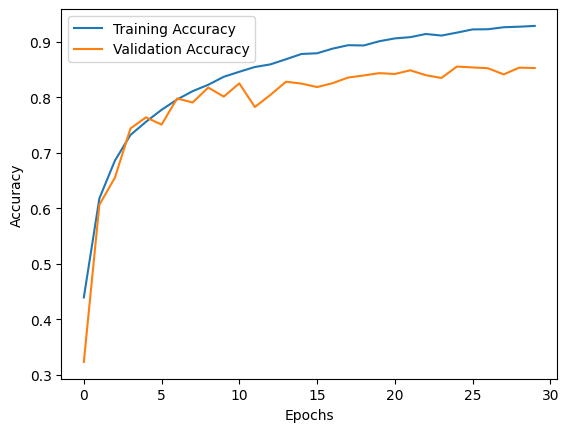

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [20]:
model_path = 'cifar10_model.h5'
model.save(model_path)